In [1]:
import pyscf
import numpy as np
import scipy as sp

import numpy as np
import scipy as sp
import pyscf

from copy import deepcopy

def ccsd_onUHF_bartlett(mf, dodiis = 8): # debug this

    Sovlp = mf.get_ovlp()
    h1e = mf.get_hcore()
    h2e = mf.mol.intor('int2e', aosym = "s1")

    # fock = mf.get_fock()

    norb = mf.mol.nao

    nelec_a = mf.nelec[0]
    nelec_b = mf.nelec[1]
    nelec = nelec_a + nelec_b

    nocc = nelec
    nvirt = 2*norb - nocc # unrestricted


    # print("successful 1")

    coeffa = mf.mo_coeff[0]
    coeffb = mf.mo_coeff[1]


    # h1e_aa = np.einsum('ij,ia,jb->ab',h1e,coeffa, coeffa)
    # h1e_bb = np.einsum('ij,ia,jb->ab', h1e, coeffb, coeffb)

    # h1e_mo = np.zeros((norb*2, norb*2))
    # h1e_mo[:norb,:norb] = h1e_aa
    # h1e_mo[norb:,norb:] = h1e_bb



    h2e_aaaa = np.einsum('ijkl,ia,jb,kc,ld->abcd',h2e,coeffa,coeffa,coeffa,coeffa, optimize = True)
    h2e_bbbb = np.einsum('ijkl,ia,jb,kc,ld->abcd',h2e,coeffb,coeffb,coeffb,coeffb, optimize = True)

    h2e_aabb = np.einsum('ijkl,ia,jb,kc,ld->abcd',h2e,coeffa,coeffa,coeffb,coeffb, optimize = True)
    h2e_bbaa = np.einsum('ijkl,ia,jb,kc,ld->abcd',h2e,coeffb,coeffb,coeffa,coeffa, optimize = True)

    h2e_mo = np.zeros((norb*2, norb*2, norb*2, norb*2))
    h2e_mo[:norb,:norb,:norb,:norb] = h2e_aaaa
    h2e_mo[:norb,:norb,norb:,norb:] = h2e_aabb
    h2e_mo[norb:,norb:,:norb,:norb] = h2e_bbaa
    h2e_mo[norb:,norb:,norb:,norb:] = h2e_bbbb


    # print("successful 2")


    nso = 2*norb

    idx_occ_alpha = np.arange(0, nelec_a)
    idx_occ_beta = np.arange(norb, norb+nelec_b)
    idx_occ = np.concatenate([idx_occ_alpha, idx_occ_beta])
    idx_all = np.arange(nso)
    idx_virt = np.setdiff1d(idx_all, idx_occ, assume_unique = True)

    perm = np.concatenate([idx_occ, idx_virt])

    # h1e_mo_sorted = h1e_mo[np.ix_(perm,perm)]
    h2e_mo_sorted = h2e_mo[np.ix_(perm,perm,perm,perm)]


    # now should be in terms of occupied, virtual for each of the indices.
    
    t2 = np.zeros((nocc,nocc,nvirt,nvirt)) # like ijab

    # initial guess is supposed to be the same as previous; <ij||ab>/Dijab


    h2e_mo_asym_chemist = h2e_mo_sorted - np.transpose(h2e_mo_sorted,(0,3,2,1)) # ai bj (normal) - aj bi (reshaped)

    # now transpose to physicist notation to match bartlett
    # a i b j --> a b i j; transpose(h2e_mo, (0, 2, 1, 3)
    h2e_mo_asym = np.transpose(h2e_mo_asym_chemist,(0, 2, 1, 3))  ## now these are < ab || ij >

    h2e_mo_asym_trunc = h2e_mo_asym[:nocc, :nocc, nocc:, nocc:]


    # t2 amplitudes antisymmetric upon pp/hh transformation
    # we need to generate our t2 guess

    # t2 has dimensions (i,j,a,b) = (occ, occ, vir, vir) = (nelec, nelec, nvirt, nvirt)

    # print("successful 3")


    mo_energy_a = mf.mo_energy[0]
    mo_energy_b = mf.mo_energy[1]

    mo_energy = np.concatenate([mo_energy_a, mo_energy_b])
    mo_energy_sorted = mo_energy[np.ix_(perm)]

    denomt2 = mo_energy_sorted[:nocc, None, None, None] + mo_energy_sorted[None, :nocc, None, None] - mo_energy_sorted[None, None, nocc:, None] - mo_energy_sorted[None, None, None, nocc:]

    denomt1 = mo_energy_sorted[:nocc, None] - mo_energy_sorted[None, nocc:] # for t1 amplitude denominator in recursion


    t2 = h2e_mo_asym_trunc / (denomt2 + 1e-11)

    # print("successful 4")
    
    converged = False

    Eccsd_prev = None

    # now we also add a guessfunction for the t1 amplitudes

    # t1 will be LIKE i, a

    t1 = np.zeros_like(denomt1, np.double) # nocc, nvirt

    # now we need to get the fock matrix in mo basis

    fock_a = mf.get_fock()[0]
    fock_b = mf.get_fock()[1]

    fock_a_mo = np.einsum('ij,ia,jb->ab', fock_a, coeffa, coeffa, optimize=True)
    fock_b_mo = np.einsum('ij,ia,jb->ab', fock_b, coeffb, coeffb, optimize=True)

    fock_mo = np.zeros((norb*2, norb*2))
    fock_mo[:norb, :norb] = fock_a_mo
    fock_mo[norb:, norb:] = fock_b_mo
    fock_mo_sorted = fock_mo[np.ix_(perm, perm)]

    # print(fock_mo_sorted)

    t2_prev = None
    t1_prev = None

    # print(mo_energy_sorted)
    # print(np.diag(fock_mo_sorted))

    # testing = True
    # if testing:
    #     return None

    while not converged:
        # we now implement equations for the t1 amplitudes.

        lhst1 = (
            fock_mo_sorted[:nocc,nocc:] +

            0.5 * np.einsum('akcd, ikcd->ia', h2e_mo_asym[nocc:, :nocc, nocc:, nocc:], t2, optimize=True) -
            0.5 * np.einsum('klic, klac -> ia', h2e_mo_asym[:nocc, :nocc, :nocc, nocc:], t2, optimize=True) +

            np.einsum('akic, kc -> ia', h2e_mo_asym[nocc:,:nocc,:nocc,nocc:], t1, optimize=True) -
            0.5 * np.einsum('klcd, ic, klad->ia', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t2, optimize=True) -
            0.5 * np.einsum('klcd, ka, ilcd->ia', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t2, optimize=True) +

            np.einsum('klcd,kc,lida->ia', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t2, optimize=True) +
            np.einsum('akcd, ic, kd->ia', h2e_mo_asym[nocc:,:nocc,nocc:,nocc:], t1, t1, optimize = True) -

            np.einsum('klic, ka, lc->ia', h2e_mo_asym[:nocc,:nocc,:nocc,nocc:], t1, t1, optimize=True) -
            np.einsum('klcd, ic, ka, ld->ia', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t1, t1, optimize=True)
        )


        lhs_ccd = (
            h2e_mo_asym[:nocc, :nocc, nocc:, nocc:] + 
                    #i j a b

            0.5*np.einsum('abcd,ijcd->ijab',h2e_mo_asym[nocc:,nocc:,nocc:,nocc:],t2, optimize = True) + 
                    # do i need to include the offdiagonal parts of fockmatrix?


            0.5 * np.einsum('klij,klab->ijab',h2e_mo_asym[:nocc,:nocc,:nocc,:nocc],t2, optimize = True) + 

            np.einsum('kbcj,ikac->ijab',h2e_mo_asym[:nocc,nocc:,nocc:,:nocc],t2, optimize = True) +
            np.einsum('kaci,jkbc->ijab',h2e_mo_asym[:nocc,nocc:,nocc:,:nocc],t2, optimize = True) - 
            np.einsum('kacj,ikbc->ijab',h2e_mo_asym[:nocc,nocc:,nocc:,:nocc], t2, optimize = True) -
            np.einsum('kbci,jkac->ijab',h2e_mo_asym[:nocc,nocc:,nocc:,:nocc],t2, optimize = True) + 

            0.25 * np.einsum('klcd,ijcd,klab->ijab',h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t2, t2, optimize = True) +

            np.einsum('klcd,ikac,jlbd->ijab',h2e_mo_asym[:nocc,:nocc,nocc:,nocc:],t2,t2, optimize = True) - 
            np.einsum('klcd,jkac,ilbd->ijab',h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t2, t2, optimize = True) - 

            0.5 * np.einsum('klcd,ikdc,ljab->ijab',h2e_mo_asym[:nocc,:nocc,nocc:,nocc:],t2,t2, optimize = True) + 
            0.5*np.einsum('klcd,jkdc,liab->ijab',h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t2, t2, optimize = True) -
            0.5 * np.einsum('klcd,lkac,ijdb->ijab',h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t2, t2, optimize = True) + 
            0.5*np.einsum('klcd,lkbc,ijda->ijab',h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t2, t2, optimize = True)
        )

        # UPDATE THIS! NEED TO INCLUDE THE SMALL OFFDIAGONAL COMPONENTS.
        # Einsum over the whole thing and then subtract off the diagonal part from the LHS.

        lhs_doubles = (
            np.einsum('abcj,ic->ijab', h2e_mo_asym[nocc:,nocc:,nocc:,:nocc], t1, optimize=True) -
            np.einsum('abci,jc->ijab', h2e_mo_asym[nocc:, nocc:, nocc:, :nocc], t1, optimize = True) -

            np.einsum('kbij, ka->ijab', h2e_mo_asym[:nocc,nocc:, :nocc, :nocc], t1, optimize = True) +
            np.einsum('kaij, kb->ijab', h2e_mo_asym[:nocc,nocc:,:nocc,:nocc], t1, optimize = True) -
            
            np.einsum('kc,ic,kjab->ijab', fock_mo_sorted[:nocc,nocc:], t1, t2, optimize = True) +
            np.einsum('kc,jc,kiab->ijab', fock_mo_sorted[:nocc,nocc:], t1, t2, optimize = True) -

            np.einsum('kc,ka,ijcb->ijab', fock_mo_sorted[:nocc,nocc:], t1, t2, optimize = True) +
            np.einsum('kc,kb,ijca->ijab', fock_mo_sorted[:nocc,nocc:], t1, t2, optimize = True) +

            # try replacing fock_mo_sorted with the sorted energies instead! mo_energy_sorted = mo_energy[np.ix_(perm)]
            # actually unnecexsary; we act on HF state hence fock matrix diagonal. So the terms vanish.


            np.einsum('akcd, ic, kjdb->ijab', h2e_mo_asym[nocc:,:nocc,nocc:,nocc:], t1, t2, optimize = True) -
            np.einsum('akcd, jc,kidb->ijab', h2e_mo_asym[nocc:,:nocc,nocc:,nocc:], t1, t2, optimize = True) -
            np.einsum('bkcd,ic,kjda->ijab', h2e_mo_asym[nocc:,:nocc,nocc:,nocc:], t1, t2, optimize = True) + # TYPO CAUGHT
            np.einsum('bkcd,jc,kida->ijab', h2e_mo_asym[nocc:,:nocc,nocc:,nocc:], t1, t2, optimize = True) -

            np.einsum('klic,ka,ljcb->ijab', h2e_mo_asym[:nocc,:nocc,:nocc,nocc:], t1, t2, optimize = True) +
            np.einsum('kljc,ka,licb->ijab', h2e_mo_asym[:nocc,:nocc,:nocc,nocc:], t1, t2, optimize = True) +
            np.einsum('klic,kb,ljca->ijab', h2e_mo_asym[:nocc,:nocc,:nocc,nocc:], t1, t2, optimize = True) -
            np.einsum('kljc,kb,lica->ijab', h2e_mo_asym[:nocc,:nocc,:nocc,nocc:], t1, t2, optimize = True) -

            0.5 * np.einsum('kbcd,ka,ijcd->ijab', h2e_mo_asym[:nocc,nocc:,nocc:,nocc:], t1, t2, optimize = True) +
            0.5 * np.einsum('kacd, kb, ijcd->ijab', h2e_mo_asym[:nocc,nocc:,nocc:,nocc:], t1, t2, optimize = True) + # end pg307

            0.5 * np.einsum('klcj,ic,klab->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,:nocc], t1, t2, optimize = True) -
            0.5 * np.einsum('klci, jc, klab->ijab', h2e_mo_asym[:nocc, :nocc, nocc:, :nocc], t1, t2, optimize = True) +

            np.einsum('kacd,kc,ijdb->ijab', h2e_mo_asym[:nocc,nocc:,nocc:,nocc:], t1, t2, optimize = True) -
            np.einsum('kbcd,kc,ijda->ijab', h2e_mo_asym[:nocc,nocc:,nocc:,nocc:], t1, t2, optimize = True) -

            np.einsum('klci,kc,ljab->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,:nocc], t1, t2, optimize = True) +
            np.einsum('klcj,kc,liab->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,:nocc], t1, t2, optimize = True) +
            
            np.einsum('abcd,ic,jd->ijab', h2e_mo_asym[nocc:,nocc:,nocc:,nocc:], t1, t1, optimize = True) +

            np.einsum('klij,ka,lb->ijab', h2e_mo_asym[:nocc,:nocc,:nocc,:nocc], t1, t1, optimize = True) -

            np.einsum('kbcj,ic,ka->ijab', h2e_mo_asym[:nocc,nocc:,nocc:,:nocc], t1, t1, optimize = True) +
            np.einsum('kbci,jc,ka->ijab', h2e_mo_asym[:nocc,nocc:,nocc:,:nocc], t1, t1, optimize = True) +
            np.einsum('kacj,ic,kb->ijab', h2e_mo_asym[:nocc,nocc:,nocc:,:nocc], t1, t1, optimize = True) -
            np.einsum('kaci,jc,kb->ijab', h2e_mo_asym[:nocc,nocc:,nocc:,:nocc], t1, t1, optimize = True) +

            0.5 * np.einsum('klcd,ic,jd,klab->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t1, t2, optimize = True) +

            0.5 * np.einsum('klcd, ka, lb,ijcd->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t1, t2, optimize = True) -

            np.einsum('klcd,ic,ka,ljdb->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t1, t2, optimize = True) +
            np.einsum('klcd,jc,ka,lidb->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t1, t2, optimize = True) +
            np.einsum('klcd,ic,kb,ljda->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t1, t2, optimize = True) -
            np.einsum('klcd,jc,kb,lida->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t1, t2, optimize = True) -

            np.einsum('klcd,kc,id,ljab->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t1, t2, optimize = True) +
            np.einsum('klcd,kc,jd,liab->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t1, t2, optimize = True) -

            np.einsum('klcd,kc,la,ijdb->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t1, t2, optimize = True) +
            np.einsum('klcd, kc,lb,ijda->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t1, t2, optimize = True) +

            np.einsum('kbcd,ic,ka,jd->ijab', h2e_mo_asym[:nocc,nocc:,nocc:,nocc:], t1, t1, t1, optimize = True) -
            np.einsum('kacd,ic,kb,jd->ijab', h2e_mo_asym[:nocc,nocc:,nocc:,nocc:], t1, t1, t1, optimize = True) +

            np.einsum('klcj,ic,ka,lb->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,:nocc], t1, t1, t1, optimize = True) -
            np.einsum('klci,jc,ka,lb->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,:nocc], t1, t1, t1, optimize = True) +

            np.einsum('klcd,ic,jd,ka,lb->ijab', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t1, t1, t1, optimize = True)

        )

        lhst2 = lhs_ccd + lhs_doubles

        t2 = lhst2/(denomt2 + 1e-11)
        t1 = lhst1/(denomt1 + 1e-11)

        Eccsd = (
            0.25*np.einsum('ijab, ijab->',h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t2, optimize = True) +
            np.einsum('ia,ia->', fock_mo_sorted[:nocc,nocc:], t1, optimize = True) +
            0.5 * np.einsum('ijab,ia,jb->', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t1, optimize = True)
        )
            
        # Eccsd = (
        #     0.25*np.einsum('ijab,ijab->',h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t2) +
        #     0.25 * np.einsum('ijab,ia,jb->', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1 ,t1) -
        #     0.25 * np.einsum('ijab,ib,ja->', h2e_mo_asym[:nocc,:nocc,nocc:,nocc:], t1, t1)
        # )

        
        # if Eccsd_prev is not None:
        #     if np.abs(Eccsd - Eccsd_prev) < 1e-8:
        #         converged = True

        if Eccsd_prev is not None:
            if np.abs(Eccsd - Eccsd_prev) < 1e-12 and np.linalg.norm(t2 - t2_prev) < 1e-12 and np.linalg.norm(t1 - t1_prev) < 1e-12:
                converged = True
                    # break

        # if t2_prev is not None:
        #     if np.linalg.norm(t2 - t2_prev) < 1e-6 and np.linalg.norm(t1 - t1_prev) < 1e-6:
        #         converged = True

        Eccsd_prev = Eccsd
        t2_prev = t2
        t1_prev = t1           


        print(Eccsd)
    
    return Eccsd, t1, t2


In [3]:
import numpy as np
import scipy as sp
import pyscf
from pyscf import gto, scf

mol = gto.Mole()
mol.atom = """
He    0.0    0.0    0.0
He    1.0    0.0    0.0
B    0.5    0.866    0.0
"""
mol.basis = '6-31g'
mol.charge = 0
mol.spin = 3
mol.build()



mf = scf.UHF(mol)

# Tighten SCF convergence criteria
mf.conv_tol = 1e-12       # Energy convergence tolerance
mf.conv_tol_grad = 1e-12   # Gradient convergence tolerance
mf.max_cycle = 1000        # Max SCF iterations
mf.kernel()  

converged SCF energy = -29.671294469557  <S^2> = 3.7505381  2S+1 = 4.000269


-29.67129446955699

In [9]:
import pyscf.cc as cc

mycc = cc.uccsd.CCSD(mf)
mycc.kernel()


E(UCCSD) = -29.7124846646975  E_corr = -0.04119019514051086


(-0.04119019514051086,
 (array([[-7.13180409e-05,  3.73891471e-04,  2.21777055e-17,
           1.17532594e-16, -2.82446797e-04, -1.75247572e-16,
           1.16562388e-04],
         [ 3.62005730e-03,  2.80136703e-03,  1.78712574e-16,
           5.69280280e-16,  1.60718908e-03, -6.70154143e-16,
           2.29314861e-03],
         [-1.04227385e-15, -1.00925937e-15,  4.67062082e-19,
           2.33310929e-04, -1.34503156e-15, -2.80172282e-03,
           3.31058426e-16],
         [-1.65674908e-03, -3.20408722e-03, -1.62250933e-16,
          -9.93585601e-16, -1.57878995e-04,  1.24907103e-16,
          -4.70970521e-04],
         [ 1.24600653e-16, -3.24636381e-16,  3.15103176e-03,
           4.71547236e-17,  1.48820787e-16, -1.24244879e-18,
          -6.39334247e-19],
         [-1.43624142e-15,  6.18219430e-16, -1.89601076e-17,
           7.58376002e-05,  2.25950437e-15, -7.49923465e-04,
          -4.36613241e-17]]),
  array([[ 2.01644172e-04,  4.07290057e-19, -1.06135049e-16,
           6.1

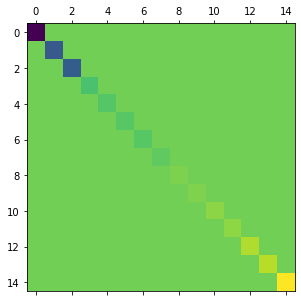

In [68]:
import matplotlib.pyplot as plt

fock_ao = mf.get_fock()
mocoeffs = mf.mo_coeff
alphamo = mocoeffs[0]
betamo = mocoeffs[1]
# print(alphamo.T @ fock_ao[0] @ alphamo)
plt.matshow(alphamo.T @ fock_ao[0] @ alphamo)

In [10]:
import pyscf.cc as cc

gmf = scf.convert_to_ghf(mf)

myccg = cc.gccsd.GCCSD(gmf)
myccg.kernel()

E(GCCSD) = -29.7124846646975  E_corr = -0.04119019514051096


(-0.04119019514051096,
 array([[ 0.00000000e+00,  0.00000000e+00, -7.13180409e-05,
          0.00000000e+00,  0.00000000e+00,  3.73891471e-04,
          2.21777055e-17,  1.17905340e-16,  0.00000000e+00,
         -2.82446797e-04,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00, -1.73896457e-16,  0.00000000e+00,
          1.16562388e-04,  0.00000000e+00],
        [ 2.01644172e-04,  4.07290057e-19,  0.00000000e+00,
         -1.07127803e-16,  6.14537320e-05,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  2.79990634e-04,
          0.00000000e+00, -2.12123156e-17,  1.06409646e-18,
         -1.30863255e-04,  0.00000000e+00,  2.54915466e-17,
          0.00000000e+00,  1.15969200e-04],
        [ 0.00000000e+00,  0.00000000e+00,  3.62005730e-03,
          0.00000000e+00,  0.00000000e+00,  2.80136703e-03,
          1.78712574e-16,  4.85278907e-16,  0.00000000e+00,
          1.60718908e-03,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00, -3.56462796e-16,  0.000

In [12]:
mycc.t1

(array([[-7.13180409e-05,  3.73891471e-04,  2.21777055e-17,
          1.17532594e-16, -2.82446797e-04, -1.75247572e-16,
          1.16562388e-04],
        [ 3.62005730e-03,  2.80136703e-03,  1.78712574e-16,
          5.69280280e-16,  1.60718908e-03, -6.70154143e-16,
          2.29314861e-03],
        [-1.04227385e-15, -1.00925937e-15,  4.67062082e-19,
          2.33310929e-04, -1.34503156e-15, -2.80172282e-03,
          3.31058426e-16],
        [-1.65674908e-03, -3.20408722e-03, -1.62250933e-16,
         -9.93585601e-16, -1.57878995e-04,  1.24907103e-16,
         -4.70970521e-04],
        [ 1.24600653e-16, -3.24636381e-16,  3.15103176e-03,
          4.71547236e-17,  1.48820787e-16, -1.24244879e-18,
         -6.39334247e-19],
        [-1.43624142e-15,  6.18219430e-16, -1.89601076e-17,
          7.58376002e-05,  2.25950437e-15, -7.49923465e-04,
         -4.36613241e-17]]),
 array([[ 2.01644172e-04,  4.07290057e-19, -1.06135049e-16,
          6.14537320e-05,  2.79990634e-04, -1.81455259e-

In [6]:
ccsd_onUHF_bartlett(mf)

# so then need to include off-diagonal fock matrix elements!

-0.03889393035932907
-0.040541201711337
-0.040989493481254295
-0.041123209759440046
-0.04116637325218448
-0.041181288235440754
-0.04118673457500514
-0.04118881051532632
-0.041189627928899325
-0.04118995782518105
-0.041190093536467305
-0.041190150229660154
-0.041190174220477174
-0.04119018448756514
-0.04119018892632104
-0.04119019086343946
-0.041190191716320115
-0.041190192094992126
-0.04119019226446974
-0.04119019234090228
-0.04119019237562444
-0.0411901923915078
-0.04119019239882133
-0.04119019240220979
-0.04119019240378886
-0.041190192404528765
-0.04119019240487724
-0.04119019240504213
-0.041190192405120514
-0.041190192405157915
-0.04119019240517584
-0.04119019240518444
-0.04119019240518861


(-0.04119019240518861,
 array([[-7.13179605e-05,  3.73891526e-04,  2.22126284e-17,
          1.16813089e-16, -2.82447193e-04, -1.76007163e-16,
          1.16562380e-04, -0.00000000e+00, -0.00000000e+00,
         -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         -0.00000000e+00, -0.00000000e+00],
        [ 3.62005211e-03,  2.80136826e-03,  1.78351641e-16,
          4.46258011e-16,  1.60718977e-03, -7.00065255e-16,
          2.29314601e-03, -0.00000000e+00, -0.00000000e+00,
         -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         -0.00000000e+00, -0.00000000e+00],
        [-1.10413327e-15, -1.57211895e-15,  8.57923319e-19,
          2.33320515e-04, -6.76939041e-16, -2.80171069e-03,
          4.21807267e-16, -0.00000000e+00, -0.00000000e+00,
         -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         -0.00000000e+00, -0.00000000e+00, -0.000

In [ ]:
# now want to calculate Lambda

In [14]:
l1, l2 = mycc.solve_lambda()